## Example plotting following [ASP Docs Section 8.3](https://stereopipeline.readthedocs.io/en/latest/examples/ctx.html#mars-reconnaissance-orbiter-ctx) for Mars Reconnaissance Orbiter (MRO) CTX camera

Below are example `asp_plot` outputs following the processing in ASP Docs Mars CTX example [Section 8.3](https://stereopipeline.readthedocs.io/en/latest/examples/ctx.html#mars-reconnaissance-orbiter-ctx).

Retrieve `.IMG` files:

```bash
wget https://planetarydata.jpl.nasa.gov/img/data/mro/ctx/mrox_0031/data/P02_001981_1823_XI_02N356W.IMG

wget https://planetarydata.jpl.nasa.gov/img/data/mro/ctx/mrox_0042/data/P03_002258_1817_XI_01N356W.IMG
```

---

[Install ISIS](https://astrogeology.usgs.gov/docs/how-to-guides/environment-setup-and-maintenance/installing-isis-via-anaconda/#installing-isis) and pre-process the images for stereo:

```bash
ISIS> mroctx2isis from=P02_001981_1823_XI_02N356W.IMG to=P02_001981_1823.cub
ISIS> mroctx2isis from=P03_002258_1817_XI_01N356W.IMG to=P03_002258_1817.cub
ISIS> spiceinit from=P02_001981_1823.cub web=false
ISIS> spiceinit from=P03_002258_1817.cub web=false
ISIS> ctxcal from=P02_001981_1823.cub to=P02_001981_1823.cal.cub
ISIS> ctxcal from=P03_002258_1817.cub to=P03_002258_1817.cal.cub
ISIS> cam2map4stereo.py P02_001981_1823.cal.cub P03_002258_1817.cal.cub
```

---

Run stereo processing and point2dem:

```bash
parallel_stereo                                      \
  --stereo-algorithm asp_mgm --subpixel-mode 9       \
  P02_001981_1823.map.cub P03_002258_1817.map.cub    \
        results/out

point2dem -r mars --stereographic --auto-proj-center \
  results/out-PC.tif
```

## Full report

Example command for full stereo-processing report

In [ ]:
directory = "~/Desktop/asp-plot-examples/mars_ctx/"
stereo_directory = "results/"

In [ ]:
!asp_report \
  --directory $directory \
  --stereo-directory $stereo_directory \
  --subset-km 1 \
  --no-basemap \
  --no-altimetry \
  --no-geometry

## Individual plots

Example modular usage of `asp_plot` for this example processing.

### Processing Parameters

In [3]:
%load_ext autoreload
%autoreload 2

from asp_plot.processing_parameters import ProcessingParameters

In [4]:
processing_parameters = ProcessingParameters(
    processing_directory=directory,
    stereo_directory=stereo_directory
)
processing_parameters_dict = processing_parameters.from_log_files()

print(f"Processed on: {processing_parameters_dict['processing_timestamp']}\n")

print(f"Reference DEM: {processing_parameters_dict['reference_dem']}\n")

print(f"Bundle adjustment ({processing_parameters_dict['bundle_adjust_run_time']}):\n")
print(processing_parameters_dict["bundle_adjust"])

print(f"\nStereo ({processing_parameters_dict['stereo_run_time']}):\n")
print(processing_parameters_dict["stereo"])

print(f"\nPoint2dem ({processing_parameters_dict['point2dem_run_time']}):\n")
print(processing_parameters_dict["point2dem"])

Processed on: 2025-10-31 11:17:37

Reference DEM: 

Bundle adjustment (N/A):

Bundle adjustment not run

Stereo (1 hours and 5 minutes):

stereo --stereo-algorithm asp_mgm --subpixel-mode 9 --corr-seed-mode 1 --compute-point-cloud-center-only --threads 40 P02_001981_1823.map.cub P03_002258_1817.map.cub results/out

Point2dem (0 hours and 11 minutes):

point2dem -r mars --stereographic --auto-proj-center results/out-PC.tif


### Scene Plots

In [5]:
from asp_plot.scenes import ScenePlotter

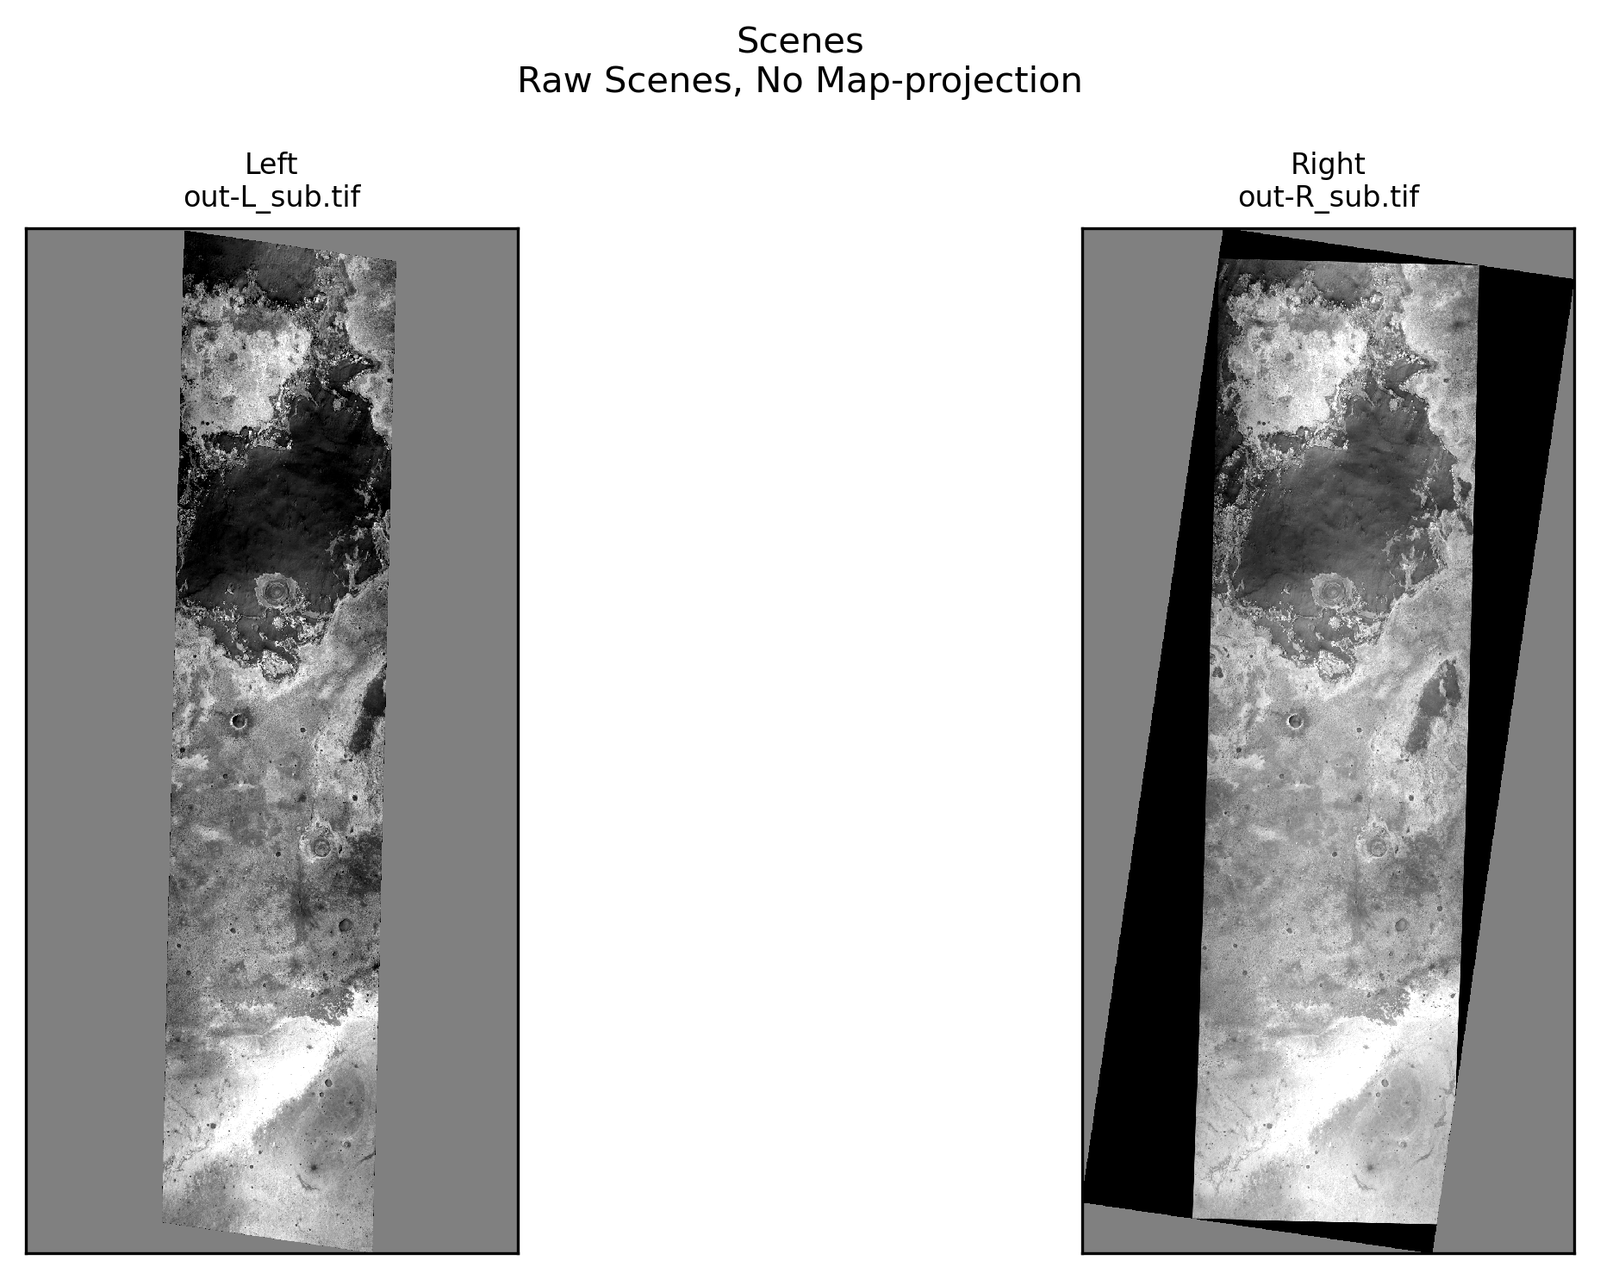

In [6]:
plotter = ScenePlotter(
  directory,
  stereo_directory,
  title="Scenes"
)

plotter.plot_scenes()

### Stereo Plots

In [7]:
from asp_plot.stereo import StereoPlotter

In [8]:
plotter = StereoPlotter(
  directory, 
  stereo_directory
)


No reference DEM found in log files. Please supply the reference DEM you used during stereo processing (or another reference DEM) if you would like to see some difference maps.





ASP DEM: ~/Desktop/asp-plot-examples/mars_ctx/results/out-DEM.tif




Intersection error file not found. Plotting hillshade without details.


/Users/ben/miniforge3/envs/asp_plot/lib/python3.13/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


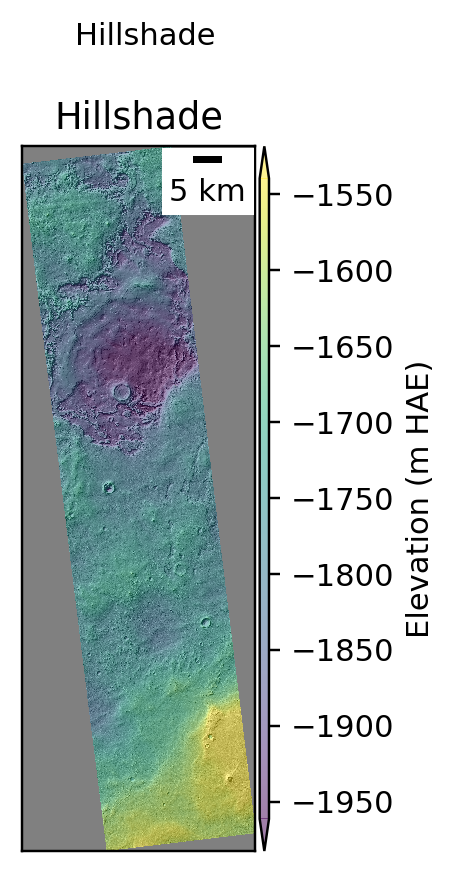

In [9]:
plotter.title = "Hillshade"

plotter.plot_detailed_hillshade()

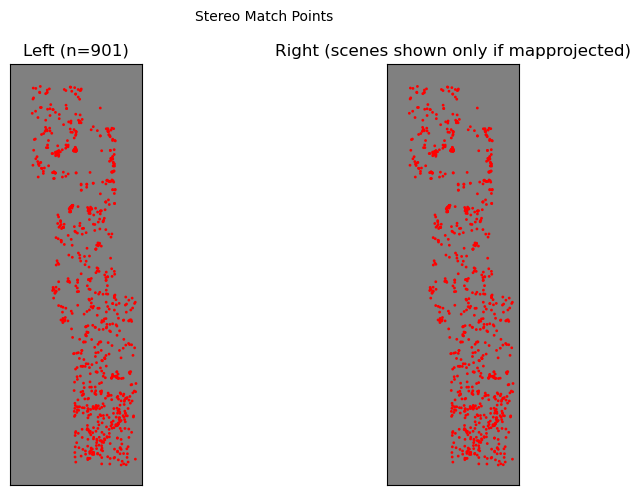

In [10]:
plotter.title="Stereo Match Points"

plotter.plot_match_points()

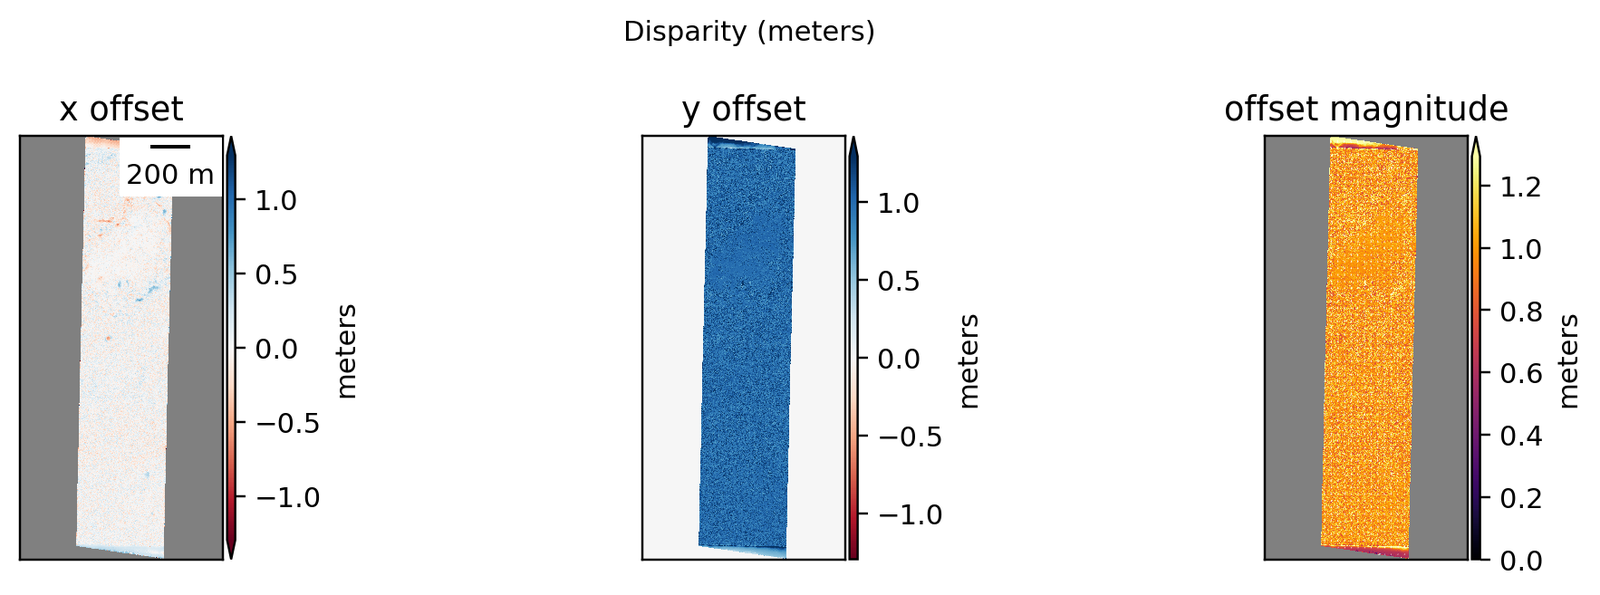

In [11]:
plotter.title = "Disparity (meters)"

plotter.plot_disparity(
  unit="meters",
  quiver=True,
)

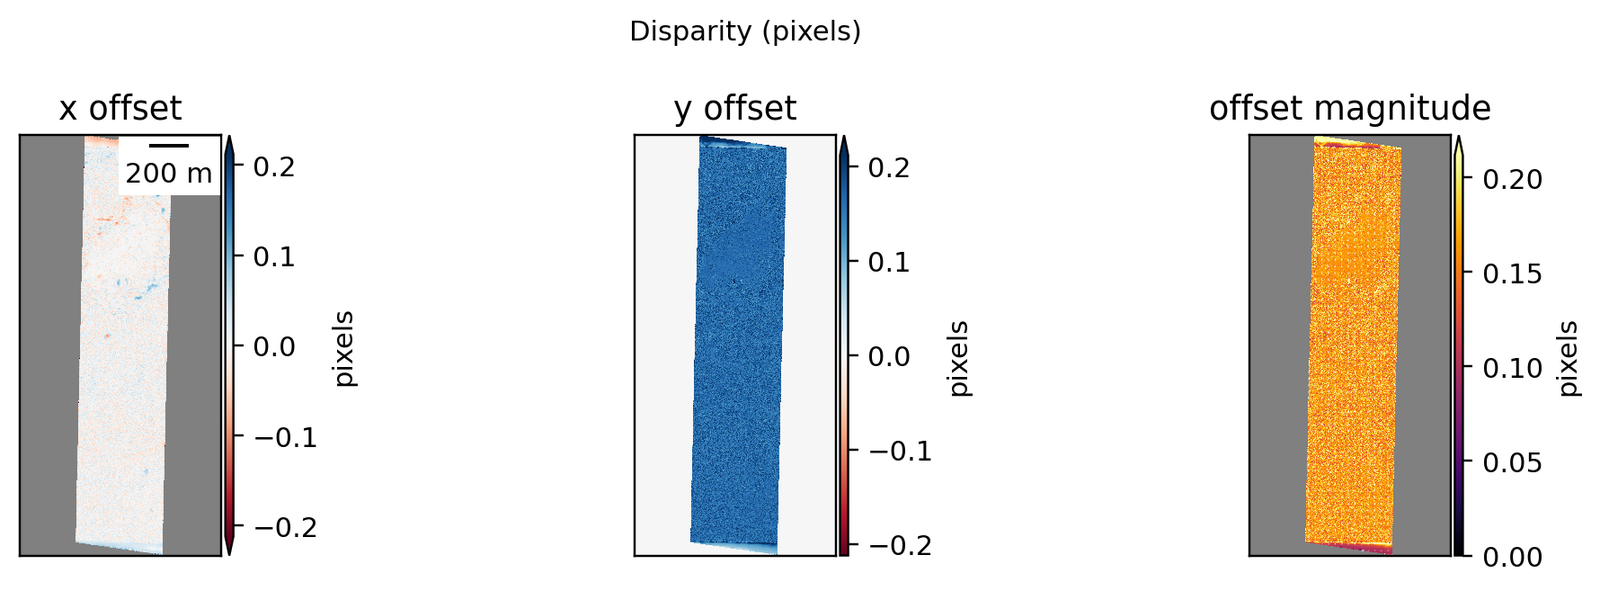

In [12]:
plotter.title = "Disparity (pixels)"

plotter.plot_disparity(
  unit="pixels",
  quiver=True,
)

Plotting DEM results. This can take a minute for large inputs.


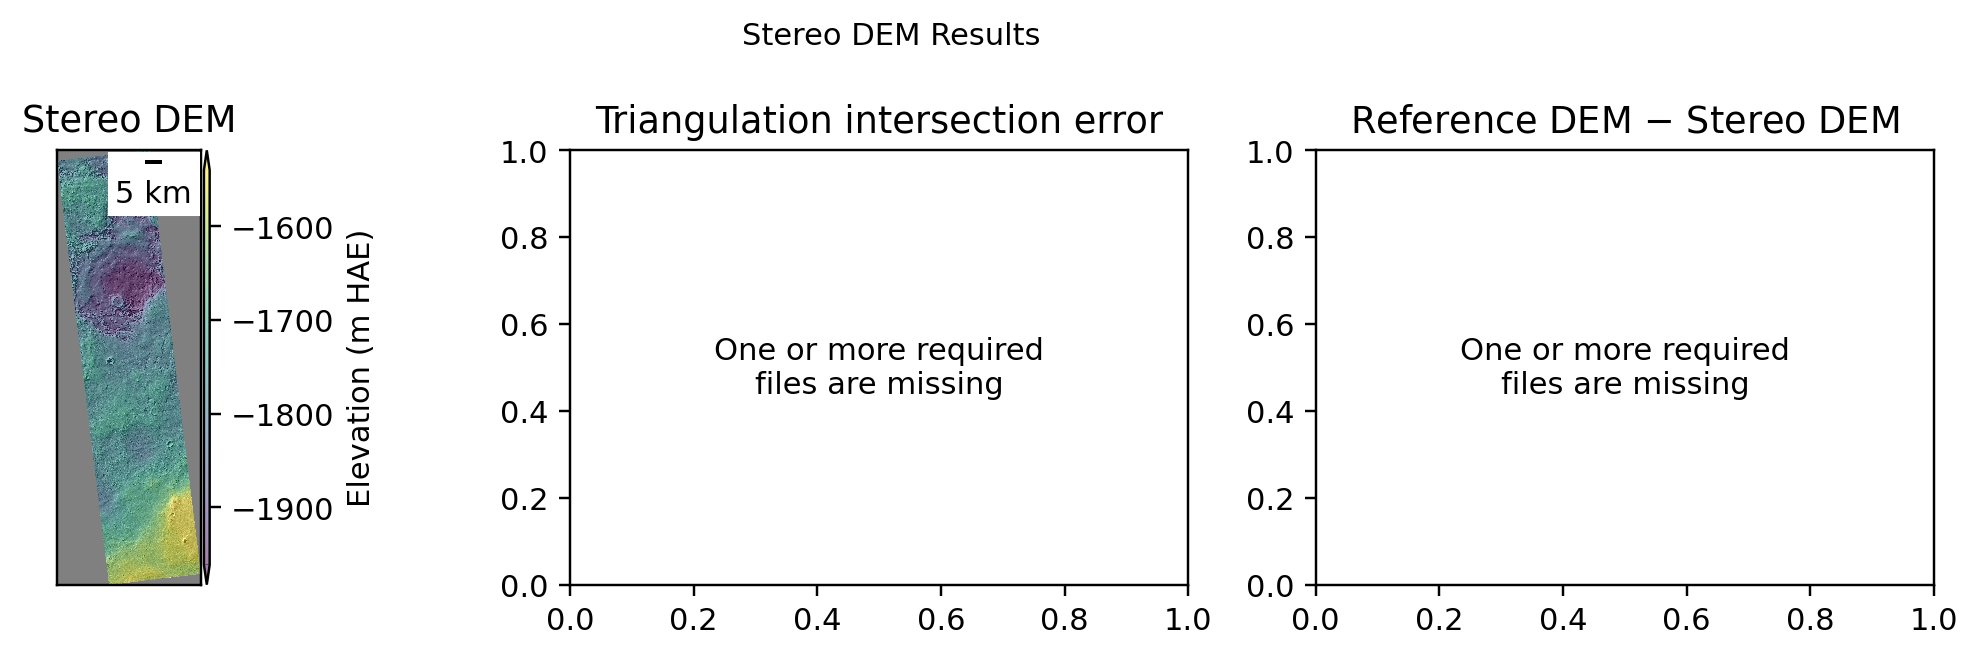

In [13]:
plotter.title = "Stereo DEM Results"

plotter.plot_dem_results()